In [38]:
import pandas as pd
import numpy as np


In [39]:
# 1. Links diretos para os arquivos originais no repositório da UCI
url_tinto = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
url_branco = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

In [40]:
# 3. Criando uma coluna nova para identificar o tipo do vinho antes de misturar os dados
df_tinto['tipo_vinho'] = 'tinto'
df_branco['tipo_vinho'] = 'branco'

In [41]:
# 4. Juntando os dois datasets em um só (concatenação)
df_vinhos = pd.concat([df_tinto, df_branco], ignore_index=True)

In [42]:
# 5. Visualizando as primeiras linhas do dataset completo
df_vinhos.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,tipo_vinho
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,tinto
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,tinto
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,tinto
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,tinto
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,tinto


Correlação entre Álcool e Qualidade: 0.44


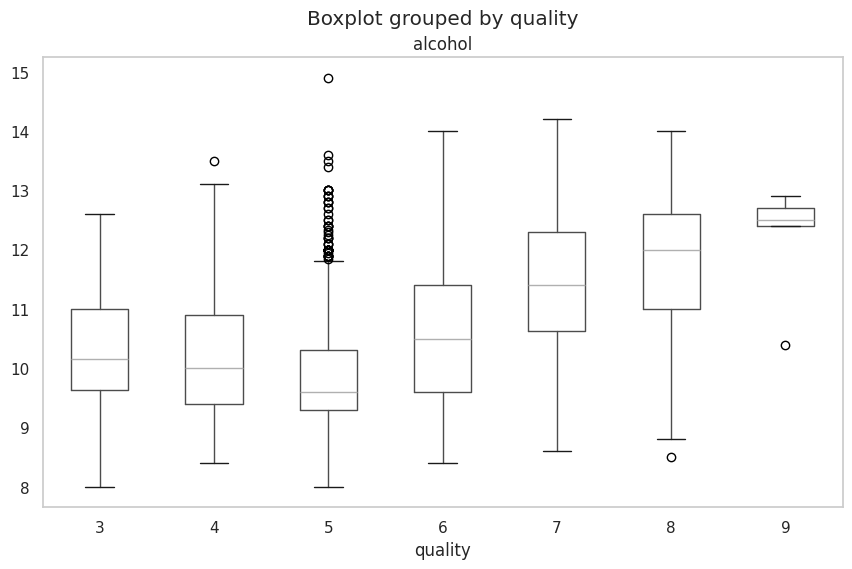

In [51]:
# Gráfico de caixa agrupado pela nota de qualidade
df_vinhos.boxplot(column='alcohol', by='quality', figsize=(10, 6), grid=False)

# A correlação continua sendo feita diretamente com o Pandas
correlacao = df_vinhos['alcohol'].corr(df_vinhos['quality'])
print(f"Correlação entre Álcool e Qualidade: {correlacao:.2f}")


In [ ]:
#Análise 1: A Influência do Álcool na Qualidade

#Como podemos observar no boxplot e no cálculo da correlação, existe uma tendência clara: vinhos avaliados com notas mais altas (7, 8 e 9) tendem a apresentar uma mediana de teor alcoólico superior aos vinhos de notas mais baixas.
#A correlação positiva indica que o nível de álcool é um dos fatores físico-químicos mais relevantes para uma boa avaliação sensorial pelos especialistas, sugerindo que vinhos mais encorpados e alcoólicos costumam agradar mais a este júri específico.

Correlação entre Acidez Volátil e Qualidade: -0.27


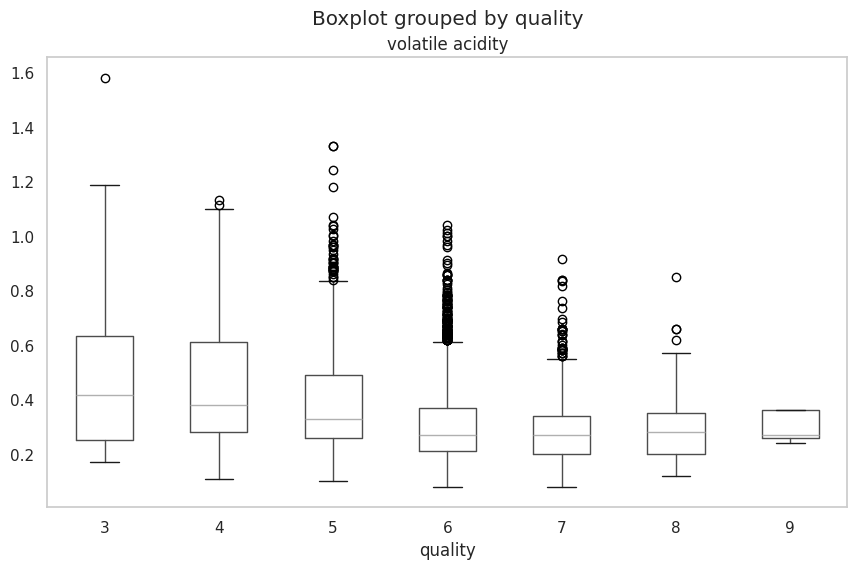

In [44]:
df_vinhos.boxplot(column='volatile acidity', by='quality', figsize=(10, 6), grid=False)

correlacao_acidez = df_vinhos['volatile acidity'].corr(df_vinhos['quality'])
print(f"Correlação entre Acidez Volátil e Qualidade: {correlacao_acidez:.2f}")

In [ ]:
#Análise 2: O Impacto Negativo da Acidez Volátil

#A acidez volátil é um indicativo da presença de ácido acético no vinho, que em níveis elevados pode conferir um sabor desagradável de vinagre.
#O gráfico demonstra exatamente esse comportamento: à medida que a nota de qualidade do vinho diminui, a quantidade média de acidez volátil aumenta.
#A correlação negativa confirma que o controle rigoroso (redução) desse componente durante a fermentação é um passo crítico para se obter um produto de alta qualidade.

<Axes: title={'center': 'residual sugar'}, xlabel='quality'>

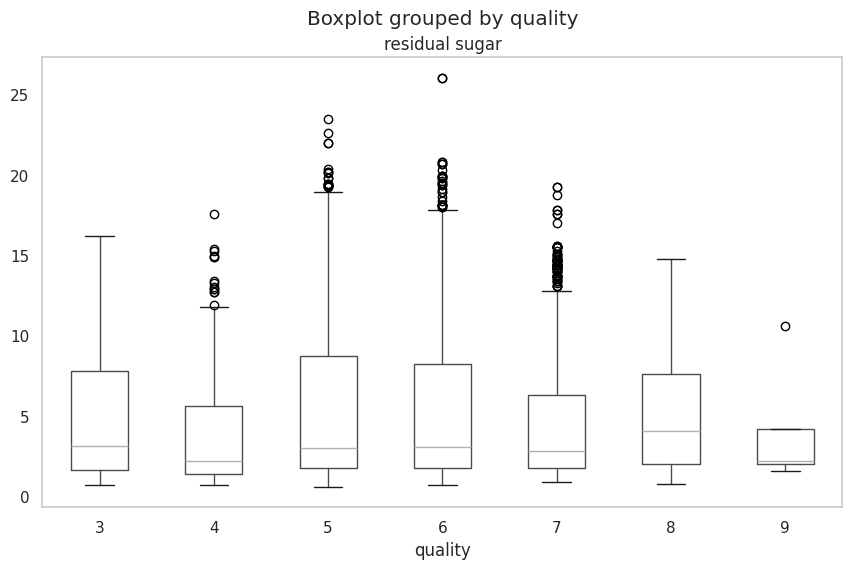

In [45]:
# Filtramos os vinhos com açúcar menor que 30 apenas para a visualização ficar mais clara
df_filtrado = df_vinhos[df_vinhos['residual sugar'] < 30]

df_filtrado.boxplot(column='residual sugar', by='quality', figsize=(10, 6), grid=False)

In [ ]:
#Análise 3: O Papel do Açúcar Residual

#Diferente do álcool e da acidez volátil, o açúcar residual não apresenta uma relação linear e direta com a qualidade.
#A distribuição no gráfico revela que tanto vinhos avaliados como excelentes quanto os de baixa qualidade concentram a maior parte de seus dados em níveis baixos de açúcar.
#Isso indica que a doçura é mais uma questão de estilo de vinho (seco vs. suave) do que um determinante absoluto de boa ou má qualidade.

<Axes: title={'center': 'chlorides'}, xlabel='[quality, tipo_vinho]'>

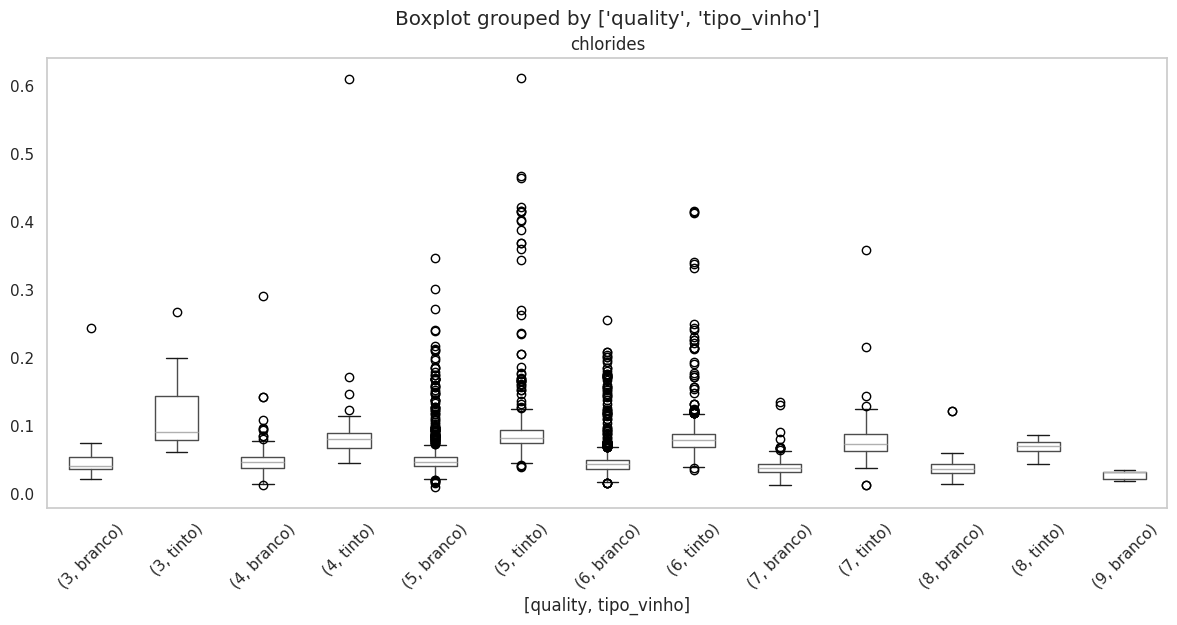

In [46]:
# O Pandas vai criar uma categoria combinada (ex: Qualidade 5, Vinho Tinto)
df_vinhos.boxplot(column='chlorides', by=['quality', 'tipo_vinho'], figsize=(14, 6), rot=45, grid=False)

In [ ]:
#Análise 4: Diferenças Estruturais entre Tipos de Vinho

#Ao utilizar a coluna tipo_vinho para separar a visualização, fica evidente que tintos e brancos possuem perfis químicos inerentemente diferentes.
#Tomando os cloretos (que influenciam a salinidade) como exemplo, notamos que os vinhos tintos apresentam, de forma consistente, concentrações maiores do que os vinhos brancos, independentemente da nota de qualidade recebida. Isso reforça a necessidade de tratar os dois tipos de vinho de forma independente em modelagens preditivas futuras.

Vinhos com densidade anormalmente alta:


,tipo_vinho,density,residual sugar,quality
3252,branco,1.01030,31.6,6
3262,branco,1.01030,31.6,6
4380,branco,1.03898,65.8,6


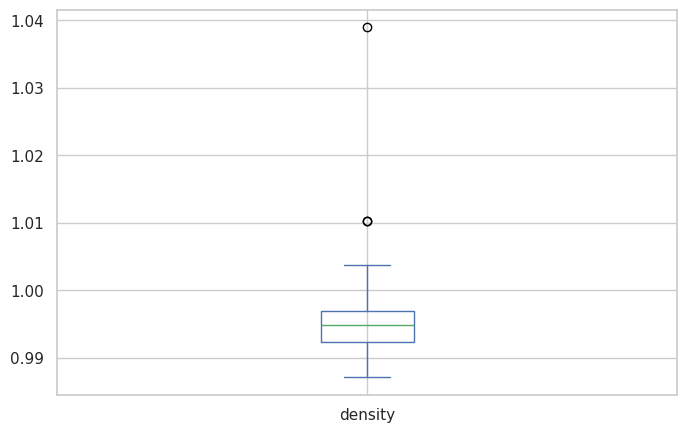

In [47]:
# Gráfico de caixa simples de uma única coluna
df_vinhos['density'].plot(kind='box', figsize=(8, 5))

# Filtro do Pandas para encontrar os valores extremos
outliers_densidade = df_vinhos[df_vinhos['density'] > 1.01]

print("Vinhos com densidade anormalmente alta:")
display(outliers_densidade[['tipo_vinho', 'density', 'residual sugar', 'quality']])

In [ ]:
#Análise 5: Investigação de Valores Atípicos (Outliers)

#A análise de distribuição apontou valores extremos (outliers) na variável de densidade.
#Ao filtrar e investigar esses dados específicos no dataframe, descobrimos que os vinhos com densidade anormalmente alta geralmente são vinhos brancos que possuem uma quantidade desproporcional de açúcar residual.